# E-Commerce Order Delivery Prediction

**Dataset:** E-Commerce Orders Dataset (12,015 rows × 13 columns)

**Goal:** Predict whether an order will be delivered on time (Classification), predict product cost (Regression), and segment customers (Clustering) using full **Scikit-learn Pipelines**.

**Target Variable:** `reached_on_time` — 1 = On Time, 0 = Delayed

## 1. Importing Packages

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

# Preprocessing
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Model Selection
from sklearn.model_selection import train_test_split

# Classification
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Regression
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Clustering
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

sns.set_theme(style="whitegrid")

In [2]:
import sys
print(sys.version)

3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 11:09:21) [Clang 14.0.6 ]


## 2. Load the Dataset

In [3]:
df = pd.read_csv('ecommerce_orders.csv')
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (12015, 13)


,order_id,customer_age,gender,product_category,order_priority,warehouse_block,mode_of_shipment,customer_rating,cost_of_the_product,prior_purchases,discount_offered,weight_in_gms,reached_on_time
0,1,56.0,Female,Home & Garden,Low,B,Ship,1.0,205.05,5,2.0,1058.0,0
1,2,NaN,Male,Toys,Low,C,Flight,2.0,64.44,4,41.0,5863.0,1
2,3,46.0,Female,Clothing,High,A,Ship,2.0,276.43,6,61.0,6969.0,1
3,4,32.0,Male,Books,Medium,A,Ship,NaN,34.02,6,29.0,2258.0,0
4,5,60.0,Male,Electronics,High,A,Road,5.0,288.50,6,30.0,4790.0,0


## 3. Exploratory Data Analysis (EDA)

### 3.1 General Overview

In [4]:
# Dataset dimensions
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12015 entries, 0 to 12014
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   order_id             12015 non-null  int64  
 1   customer_age         11414 non-null  float64
 2   gender               12015 non-null  object 
 3   product_category     12015 non-null  object 
 4   order_priority       12015 non-null  object 
 5   warehouse_block      12015 non-null  object 
 6   mode_of_shipment     12015 non-null  object 
 7   customer_rating      11564 non-null  float64
 8   cost_of_the_product  12015 non-null  float64
 9   prior_purchases      12015 non-null  int64  
 10  discount_offered     11665 non-null  float64
 11  weight_in_gms        11715 non-null  float64
 12  reached_on_time      12015 non-null  int64  
dtypes: float64(5), int64(3), object(5)
memory usage: 1.2+ MB
None


### 3.2 Numerical Features Statistics

In [5]:
df.describe()

,order_id,customer_age,customer_rating,cost_of_the_product,prior_purchases,discount_offered,weight_in_gms,reached_on_time
count,12015.00000,11414.00000,11564.000000,12015.000000,12015.000000,11665.000000,11715.000000,12015.000000
mean,5999.34149,43.51726,3.336129,253.419515,4.015814,32.463180,4015.548357,0.598169
std,3464.82248,14.90826,1.247759,346.620012,1.991680,19.059691,1736.697369,0.490289
min,1.00000,18.00000,1.000000,30.060000,1.000000,0.000000,1000.000000,0.000000
25%,2997.50000,31.00000,2.000000,88.965000,2.000000,16.000000,2526.500000,0.000000
50%,5999.00000,43.00000,3.000000,170.190000,4.000000,32.000000,4025.000000,1.000000
75%,9000.50000,56.00000,4.000000,311.520000,6.000000,49.000000,5528.500000,1.000000
max,12000.00000,69.00000,5.000000,4994.893322,7.000000,65.000000,6999.000000,1.000000


### 3.3 Categorical Features Statistics

In [6]:
df.describe(include='object')

,gender,product_category,order_priority,warehouse_block,mode_of_shipment
count,12015,12015,12015,12015,12015
unique,6,6,4,5,3
top,Male,Clothing,Medium,D,Ship
freq,6575,3620,4833,2441,7104


### 3.4 Check for Missing Values

In [7]:
print("Missing values per column:")
print(df.isna().sum())

Missing values per column:
order_id                 0
customer_age           601
gender                   0
product_category         0
order_priority           0
warehouse_block          0
mode_of_shipment         0
customer_rating        451
cost_of_the_product      0
prior_purchases          0
discount_offered       350
weight_in_gms          300
reached_on_time          0
dtype: int64


### 3.5 Check for Duplicates

In [8]:
print("Duplicate rows:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("New shape:",df.shape)

Duplicate rows: 15
New shape: (12000, 13)


### 3.6 Fix Data Quality Issues

In [9]:
df['gender'] = df['gender'].str.strip().str.title()

### 3.7 Drop Irrelevant Columns

In [10]:
df.drop(['order_id'], axis=1, inplace=True)

### 3.8 Feature Analysis & Visualizations

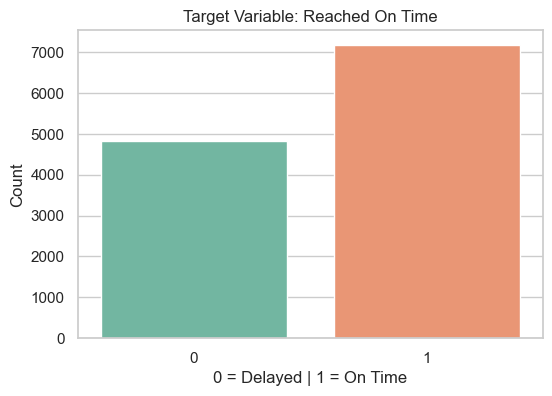

Class distribution:
reached_on_time
1    0.598
0    0.402
Name: proportion, dtype: float64


In [11]:
# Distribution of the target variable
plt.figure(figsize=(6, 4))
sns.countplot(data=df,x='reached_on_time',hue='reached_on_time',palette='Set2',legend=False)
plt.title('Target Variable: Reached On Time')
plt.xlabel('0 = Delayed | 1 = On Time')
plt.ylabel('Count')
plt.show()

print("Class distribution:")
print(df['reached_on_time'].value_counts(normalize=True).round(3))

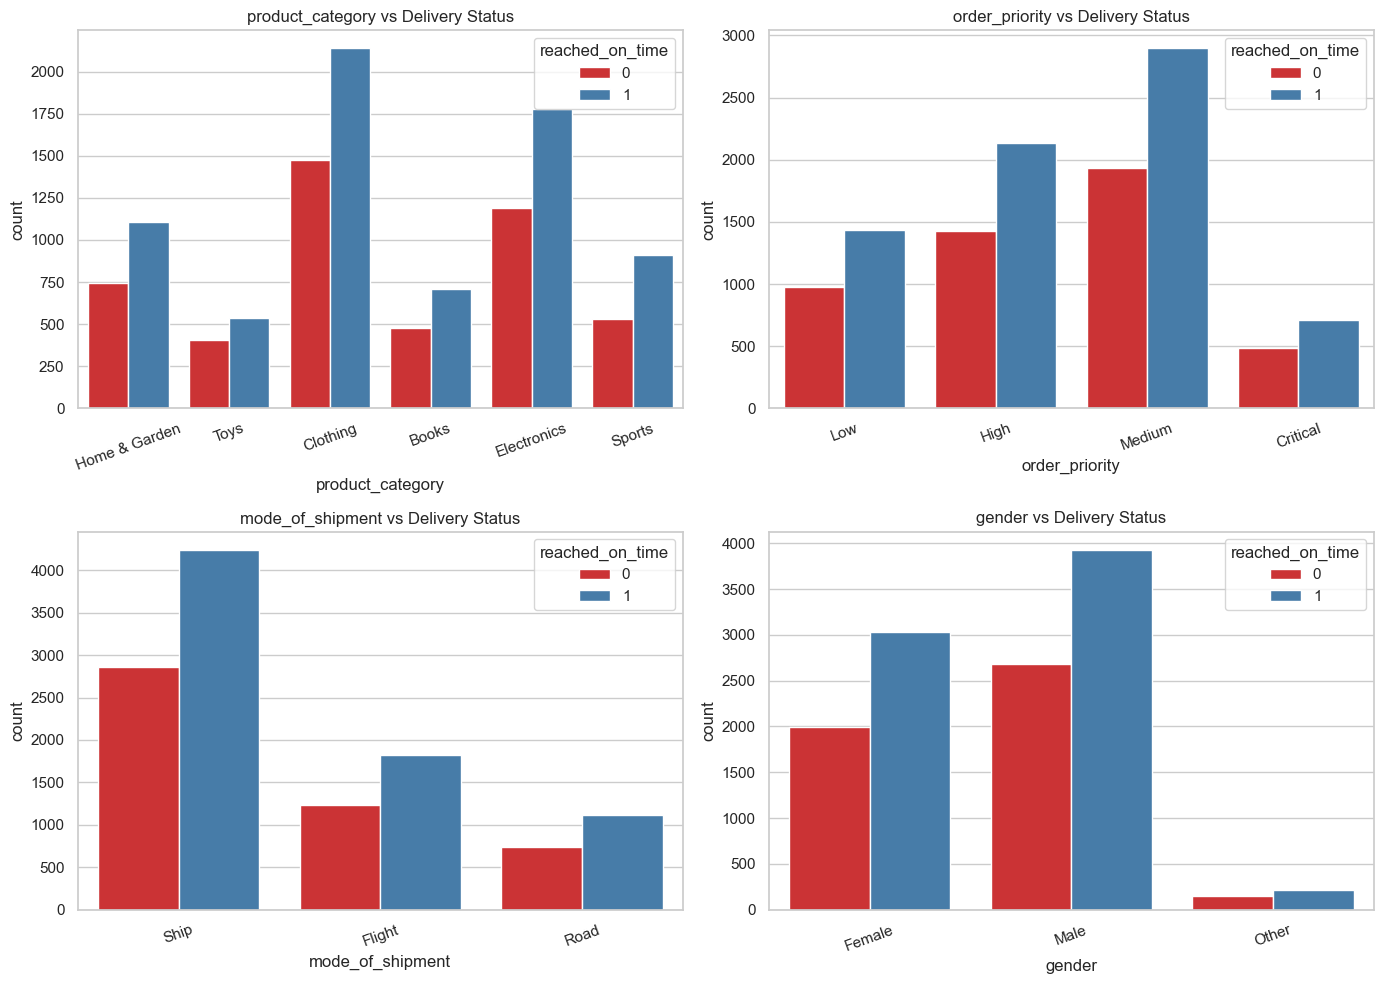

In [12]:
# Count plots for categorical features vs target
cat_features = ['product_category', 'order_priority', 'mode_of_shipment', 'gender']
fig, ax = plt.subplots(2, 2, figsize=(14, 10))
for i, subplots in zip(cat_features, ax.flatten()):
    sns.countplot(data=df, x=i, hue='reached_on_time', ax=subplots, palette='Set1')
    subplots.set_title(f'{i} vs Delivery Status')
    subplots.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

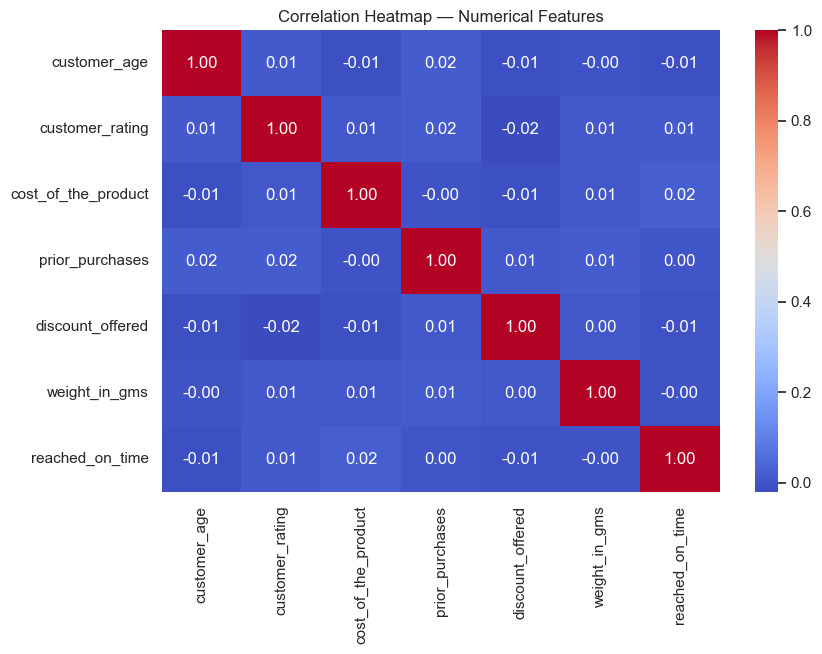

In [13]:
# Correlation heatmap for numerical features
corr = df.select_dtypes(include='number').corr()
plt.figure(figsize=(9, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap — Numerical Features')
plt.show()

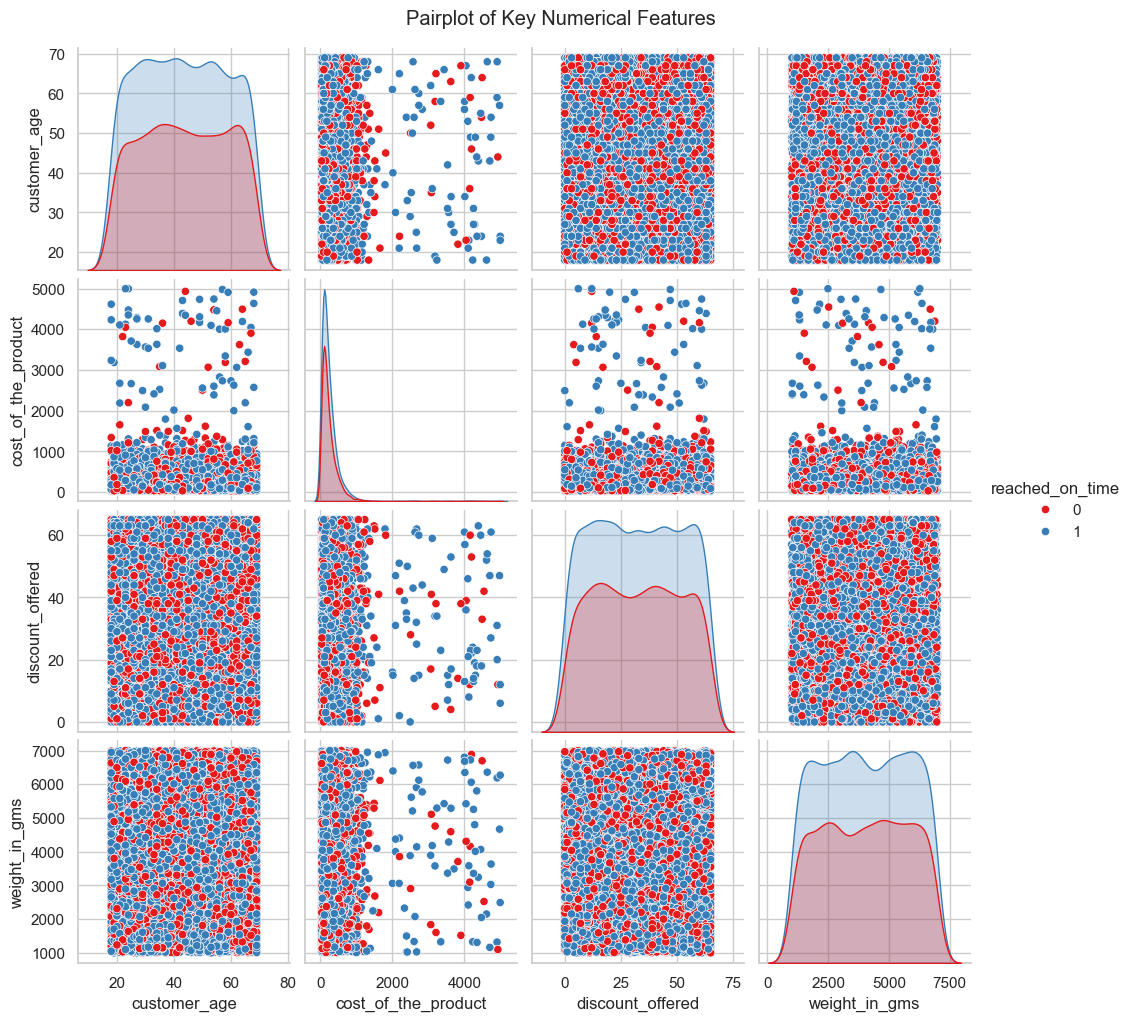

In [14]:
# Pairplot of key numerical features
sns.pairplot(df[['customer_age', 'cost_of_the_product', 'discount_offered', 'weight_in_gms', 'reached_on_time']],hue='reached_on_time', palette='Set1')
plt.suptitle('Pairplot of Key Numerical Features', y=1.02)
plt.show()

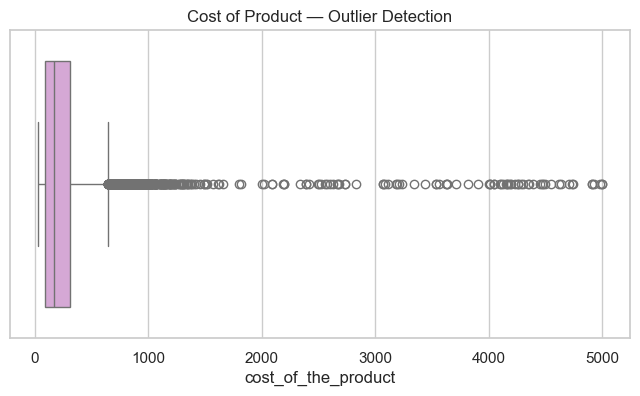

In [15]:
# Distribution of cost_of_the_product (shows outliers)
plt.figure(figsize=(8, 4))
sns.boxplot(data=df,x='cost_of_the_product',color='plum')
plt.title('Cost of Product — Outlier Detection')
plt.show()

## 4. Data Preprocessing

We follow the same pipeline approach from the labs:
1. Separate features (X) and target (y)
2. Identify numerical vs categorical columns
3. Build separate pipelines for each type
4. Combine using `ColumnTransformer`

### 4.1 Define Features and Target

In [16]:
X = df.drop(columns=['reached_on_time'])
y = df['reached_on_time']
numerical_features = X.select_dtypes(include='number').columns.tolist()
categorical_features = X.select_dtypes(include='object').columns.tolist()
print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

Numerical features: ['customer_age', 'customer_rating', 'cost_of_the_product', 'prior_purchases', 'discount_offered', 'weight_in_gms']
Categorical features: ['gender', 'product_category', 'order_priority', 'warehouse_block', 'mode_of_shipment']


### 4.2 Identify Ordinal vs Nominal Categorical Features

In [17]:
ordinal_features = ['order_priority']
ordinal_categories = [['Low', 'Medium', 'High', 'Critical']]
nominal_features = [c for c in categorical_features if c not in ordinal_features]
print("Ordinal features:", ordinal_features)
print("Nominal features:", nominal_features)

Ordinal features: ['order_priority']
Nominal features: ['gender', 'product_category', 'warehouse_block', 'mode_of_shipment']


### 4.3 Train-Test Split
> ⚠️ We split BEFORE building the pipeline to prevent data leakage.

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape: ", X_test.shape)

Training set shape: (9600, 11)
Testing set shape:  (2400, 11)


### 4.4 Build the Preprocessing Pipeline

In [19]:
# --- Numerical Pipeline ---
# Step 1: Impute missing values with the MEAN
# Step 2: Scale using Standard Scaler
numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# --- Ordinal Pipeline ---
# Step 1: Impute missing values with the most frequent value
# Step 2: Ordinal encode (Low=0, Medium=1, High=2, Critical=3)
ordinal_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=ordinal_categories))
])

# --- Nominal Pipeline ---
# Step 1: Impute missing values with the most frequent value
# Step 2: One-Hot Encode
nominal_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# --- Combine all into a ColumnTransformer ---
preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_pipeline, numerical_features),
    ('ord', ordinal_pipeline, ordinal_features),
    ('nom', nominal_pipeline, nominal_features)
])

print("Preprocessing pipeline built successfully!")

Preprocessing pipeline built successfully!


In [20]:
# Save the preprocessing pipeline for later use (e.g., Streamlit app)
joblib.dump(preprocessor, 'preprocessor.pkl')
print("Preprocessor saved as 'preprocessor.pkl'")

Preprocessor saved as 'preprocessor.pkl'


## 5. Classification — Predicting Delivery Status

**Goal:** Predict whether an order will be delivered on time (`reached_on_time`).

We will train and compare 3 classifiers:
1. Logistic Regression (baseline)
2. Support Vector Machine (SVM)
3. Random Forest (ensemble)

In [21]:
classifiers = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Support Vector Machine": SVC(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}
clf_results = {}
trained_clf_pipelines = {}
for name, clf in classifiers.items():
    model_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', clf)
    ])
    
    # Train
    model_pipeline.fit(X_train, y_train)
    
    # Predict
    y_pred = model_pipeline.predict(X_test)
    
    # Evaluate
    acc = accuracy_score(y_test, y_pred)
    clf_results[name] = acc
    trained_clf_pipelines[name] = model_pipeline
    
    print(f"--- {name} ---")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred,zero_division=0))
    print()

--- Logistic Regression ---
Accuracy: 0.5979
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       965
           1       0.60      1.00      0.75      1435

    accuracy                           0.60      2400
   macro avg       0.30      0.50      0.37      2400
weighted avg       0.36      0.60      0.45      2400


--- Support Vector Machine ---
Accuracy: 0.5979
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       965
           1       0.60      1.00      0.75      1435

    accuracy                           0.60      2400
   macro avg       0.30      0.50      0.37      2400
weighted avg       0.36      0.60      0.45      2400


--- Random Forest ---
Accuracy: 0.5700
              precision    recall  f1-score   support

           0       0.41      0.16      0.23       965
           1       0.60      0.84      0.70      1435

    accuracy                           0.57     

--- Random Forest ---
Accuracy: 0.5700
              precision    recall  f1-score   support

           0       0.41      0.16      0.23       965
           1       0.60      0.84      0.70      1435

    accuracy                           0.57      2400
   macro avg       0.51      0.50      0.47      2400
weighted avg       0.52      0.57      0.51      2400




=== Classification Model Comparison ===
  Logistic Regression: 0.5979
  Support Vector Machine: 0.5979
  Random Forest: 0.5700


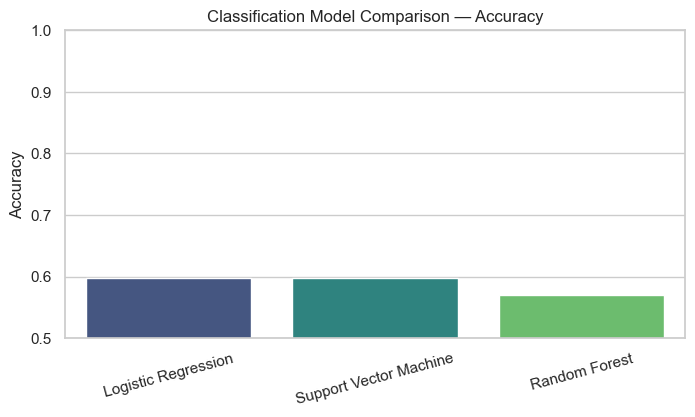

In [22]:
# Compare models
print("=== Classification Model Comparison ===")
for name, acc in sorted(clf_results.items(), key=lambda x: x[1], reverse=True):
    print(f"  {name}: {acc:.4f}")
# Visualize comparison
plt.figure(figsize=(8, 4))
sns.barplot(x=list(clf_results.keys()),y=list(clf_results.values()),hue=list(clf_results.keys()),palette='viridis',legend=False)
plt.title('Classification Model Comparison — Accuracy')
plt.ylabel('Accuracy')
plt.ylim(0.5, 1.0)
plt.xticks(rotation=15)
plt.show()

In [23]:
# Save the best classification model
best_clf_name = max(clf_results, key=clf_results.get)
best_clf_pipeline = trained_clf_pipelines[best_clf_name]

joblib.dump(best_clf_pipeline, 'best_classification_model.pkl')
print(f"Best model: {best_clf_name} (Accuracy: {clf_results[best_clf_name]:.4f})")
print("Saved as 'best_classification_model.pkl'")

Best model: Logistic Regression (Accuracy: 0.5979)
Saved as 'best_classification_model.pkl'


## 6. Regression — Predicting Product Cost

**Goal:** Predict `cost_of_the_product` (a continuous value).

We build a separate pipeline for regression, now with `cost_of_the_product` as the target.

In [24]:
# For regression: predict cost_of_the_product
X_reg = df.drop(columns=['cost_of_the_product', 'reached_on_time'])
y_reg = df['cost_of_the_product']

# Re-identify feature groups (same columns, minus the new target)
num_reg = X_reg.select_dtypes(include='number').columns.tolist()
cat_reg = X_reg.select_dtypes(include='object').columns.tolist()
ord_reg = ['order_priority']
nom_reg = [c for c in cat_reg if c not in ord_reg]

print("Regression - Numerical features:", num_reg)
print("Regression - Ordinal features:", ord_reg)
print("Regression - Nominal features:", nom_reg)

Regression - Numerical features: ['customer_age', 'customer_rating', 'prior_purchases', 'discount_offered', 'weight_in_gms']
Regression - Ordinal features: ['order_priority']
Regression - Nominal features: ['gender', 'product_category', 'warehouse_block', 'mode_of_shipment']


In [25]:
# Train-test split for regression
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Preprocessing pipeline for regression (same structure)
reg_preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([('imputer', SimpleImputer(strategy='mean')),
                      ('scaler', StandardScaler())]), num_reg),
    ('ord', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                      ('encoder', OrdinalEncoder(categories=[['Low', 'Medium', 'High', 'Critical']]))]), ord_reg),
    ('nom', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                      ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), nom_reg)
])

print("Regression preprocessor ready!")

Regression preprocessor ready!


In [26]:
# Define regression models
regressors = {
    "Linear Regression": LinearRegression(),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100, random_state=42)
}

reg_results = {}
trained_reg_pipelines = {}

for name, reg in regressors.items():
    # Full pipeline: preprocessing + regressor
    reg_pipeline = Pipeline(steps=[
        ('preprocessor', reg_preprocessor),
        ('regressor', reg)
    ])
    
    # Train
    reg_pipeline.fit(X_reg_train, y_reg_train)
    
    # Predict
    y_reg_pred = reg_pipeline.predict(X_reg_test)
    
    # Evaluate
    mse = mean_squared_error(y_reg_test, y_reg_pred)
    r2  = r2_score(y_reg_test, y_reg_pred)
    reg_results[name] = {'MSE': round(mse, 2), 'R2 Score': round(r2, 4)}
    trained_reg_pipelines[name] = reg_pipeline
    
    print(f"--- {name} ---")
    print(f"MSE:      {mse:.2f}")
    print(f"R2 Score: {r2:.4f}")
    print()

# Summary table
pd.DataFrame(reg_results).T.sort_values('R2 Score', ascending=False)

--- Linear Regression ---
MSE:      141880.65
R2 Score: -0.0011

--- Random Forest Regressor ---
MSE:      151856.70
R2 Score: -0.0715



,MSE,R2 Score
Linear Regression,141880.65,-0.0011
Random Forest Regressor,151856.70,-0.0715


In [27]:
# Save the best regression model
best_reg_name = max(reg_results, key=lambda k: reg_results[k]['R2 Score'])
best_reg_pipeline = trained_reg_pipelines[best_reg_name]

joblib.dump(best_reg_pipeline, 'best_regression_model.pkl')
print(f"Best Regression Model: {best_reg_name}")
print(f"R2 Score: {reg_results[best_reg_name]['R2 Score']}")
print("Saved as 'best_regression_model.pkl'")

Best Regression Model: Linear Regression
R2 Score: -0.0011
Saved as 'best_regression_model.pkl'


## 7. Clustering — Customer Segmentation

**Goal:** Group customers/orders into natural segments using unsupervised learning.

We use only numerical features for clustering.

In [28]:
# Use numerical features only for clustering
cluster_features = ['customer_age', 'cost_of_the_product', 'prior_purchases',
                    'discount_offered', 'weight_in_gms', 'customer_rating']

df_cluster = df[cluster_features].copy()

# Check missing values
print("Missing values in clustering features:")
print(df_cluster.isna().sum())

Missing values in clustering features:
customer_age           600
cost_of_the_product      0
prior_purchases          0
discount_offered       350
weight_in_gms          300
customer_rating        450
dtype: int64


In [29]:
# Clustering preprocessing pipeline
# Step 1: Impute missing values with mean
# Step 2: Scale with StandardScaler (KMeans is distance-based — scaling is mandatory)
cluster_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

X_cluster_scaled = cluster_pipeline.fit_transform(df_cluster)

# Save pipeline
joblib.dump(cluster_pipeline, 'cluster_preprocessor.pkl')
print("Cluster preprocessing pipeline saved!")

Cluster preprocessing pipeline saved!


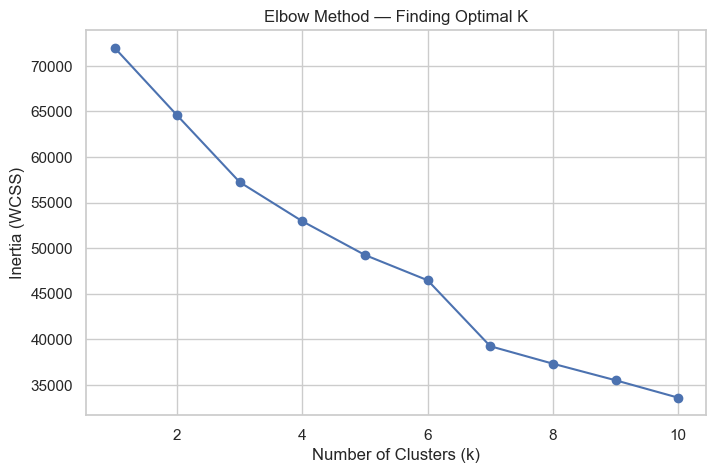

In [30]:
# Elbow Method to find optimal number of clusters (K)
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_cluster_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method — Finding Optimal K')
plt.grid(True)
plt.show()

In [31]:
# Train and compare clustering models
cluster_models = {
    "K-Means (k=4)": KMeans(n_clusters=4, random_state=42, n_init='auto'),
    "DBSCAN":        DBSCAN(eps=0.6, min_samples=5)
}

cluster_results = {}

for name, model in cluster_models.items():
    labels = model.fit_predict(X_cluster_scaled)
    unique_labels = set(labels)
    n_clusters = len([l for l in unique_labels if l != -1])
    
    if n_clusters >= 2:
        score = silhouette_score(X_cluster_scaled, labels)
    else:
        score = -1
    
    cluster_results[name] = {
        'Silhouette Score': round(score, 4),
        'Clusters Found': n_clusters,
        'Noise Points': list(labels).count(-1) if -1 in labels else 0
    }

pd.DataFrame(cluster_results).T

,Silhouette Score,Clusters Found,Noise Points
K-Means (k=4),0.1261,4.0,0.0
DBSCAN,-0.4588,126.0,3951.0


In [32]:
# Tune K-Means: find best k by silhouette score
best_k_score = -1
best_k = 2

for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = km.fit_predict(X_cluster_scaled)
    score = silhouette_score(X_cluster_scaled, labels)
    print(f"  k={k} → Silhouette Score: {score:.4f}")
    if score > best_k_score:
        best_k_score = score
        best_k = k

print(f"\nBest K: {best_k} (Silhouette Score: {best_k_score:.4f})")

  k=2 → Silhouette Score: 0.6887
  k=3 → Silhouette Score: 0.1300
  k=4 → Silhouette Score: 0.1261
  k=5 → Silhouette Score: 0.1305
  k=6 → Silhouette Score: 0.1272
  k=7 → Silhouette Score: 0.1396
  k=8 → Silhouette Score: 0.1357

Best K: 2 (Silhouette Score: 0.6887)


  k=3 → Silhouette Score: 0.1300


  k=4 → Silhouette Score: 0.1261


  k=5 → Silhouette Score: 0.1305


  k=6 → Silhouette Score: 0.1272


  k=7 → Silhouette Score: 0.1396


  k=8 → Silhouette Score: 0.1357

Best K: 2 (Silhouette Score: 0.6887)


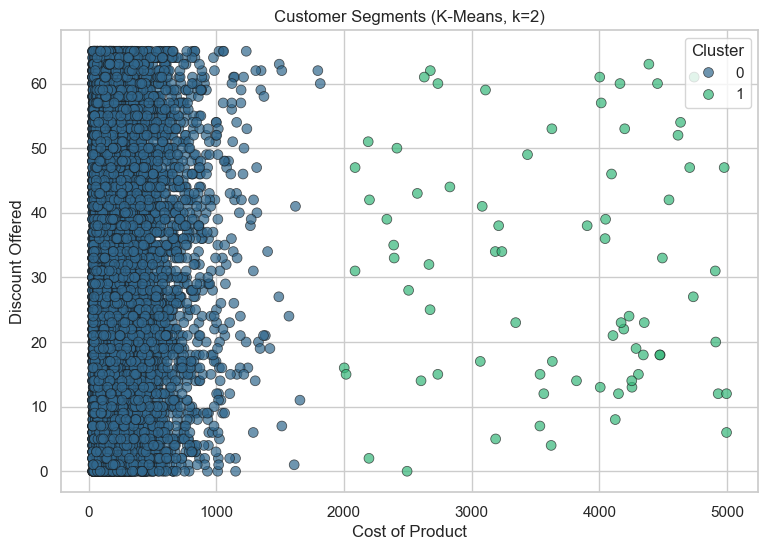

In [33]:
# Train final best clustering model
best_cluster_model = KMeans(n_clusters=best_k, random_state=42, n_init='auto')
cluster_labels = best_cluster_model.fit_predict(X_cluster_scaled)

# Add cluster labels back to original data for visualization
df_cluster['Cluster'] = cluster_labels

# Visualize clusters
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df_cluster, x='cost_of_the_product', y='discount_offered',
                hue='Cluster', palette='viridis', alpha=0.7, edgecolor='k', s=50)
plt.title(f'Customer Segments (K-Means, k={best_k})')
plt.xlabel('Cost of Product')
plt.ylabel('Discount Offered')
plt.legend(title='Cluster')
plt.show()

In [34]:
# Save clustering model
joblib.dump(best_cluster_model, 'best_clustering_model.pkl')
print(f"Clustering model saved (k={best_k}, Silhouette Score: {best_k_score:.4f})")

Clustering model saved (k=2, Silhouette Score: 0.6887)


In [35]:
import pickle

# Re-save all models
with open("best_classification_model.pkl", "wb") as f:
    pickle.dump(best_clf_pipeline, f, protocol=4)

with open("best_regression_model.pkl", "wb") as f:
    pickle.dump(best_reg_pipeline, f, protocol=4)

with open("best_clustering_model.pkl", "wb") as f:
    pickle.dump(best_cluster_pipeline, f, protocol=4)

with open("preprocessor.pkl", "wb") as f:
    pickle.dump(preprocessor, f, protocol=4)

NameError: name 'best_cluster_pipeline' is not defined

In [ ]:
pip install streamlit

In [ ]:
!streamlit run app.py


In [36]:
%whos

Variable                 Type                      Data/Info
------------------------------------------------------------
ColumnTransformer        ABCMeta                   <class 'sklearn.compose._<...>ormer.ColumnTransformer'>
DBSCAN                   type                      <class 'sklearn.cluster._dbscan.DBSCAN'>
KMeans                   ABCMeta                   <class 'sklearn.cluster._kmeans.KMeans'>
K_range                  range                     range(1, 11)
LinearRegression         ABCMeta                   <class 'sklearn.linear_mo<...>._base.LinearRegression'>
LogisticRegression       type                      <class 'sklearn.linear_mo<...>stic.LogisticRegression'>
OneHotEncoder            type                      <class 'sklearn.preproces<...>_encoders.OneHotEncoder'>
OrdinalEncoder           type                      <class 'sklearn.preproces<...>encoders.OrdinalEncoder'>
Pipeline                 ABCMeta                   <class 'sklearn.pipeline.Pipeline'>
RandomFo